# ORACLE — MedMCQA EDA
## Medical QA Domain

**Dataset:** MedMCQA — Pal et al. (2022), CHIL  
**Records:** 193,155 (train: 182,822 | test: 6,150 | validation: 4,183)  
**Labels:** Correct option (0=A, 1=B, 2=C, 3=D)  
**Domain:** Medical exam QA, English  

**Key facts:**
- 4-way MCQ across 21 medical subjects and 2,388 topics
- Slight answer bias: A=29.3%, D=21.3%
- 88% have explanations — rich for RAG retrieval
- topic_name missing 52.3% — subject_name used as primary grouping
- Dental subject only 44% explanation coverage

**Limitation:** Medical school exam questions — not patient-facing. ORACLE uses MedMCQA as retrieval baseline, not accessibility evaluation.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from medmcqa_loader import load_medmcqa_all

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

OPTION_LABELS = {0:'A (opa)', 1:'B (opb)', 2:'C (opc)', 3:'D (opd)'}
OPTION_COLORS = ['#5cb85c','steelblue','coral','#f0ad4e']
print('Imports complete')

Imports complete


In [2]:
result = load_medmcqa_all()
df = result['train']['data'].copy()
df['label'] = result['train']['labels'].values
df['q_len'] = df['question'].astype(str).str.len()
df['opa_len'] = df['opa'].astype(str).str.len()
df['opb_len'] = df['opb'].astype(str).str.len()
df['opc_len'] = df['opc'].astype(str).str.len()
df['opd_len'] = df['opd'].astype(str).str.len()
df['has_exp'] = df['exp'].notna()

print(f'Shape: {df.shape}')
print(f'Subjects: {df["subject_name"].nunique()}')
print(f'Train records: {len(df):,}')

Loading MedMCQA — all splits...


  train: 182,822 records
  test: 6,150 records
  validation: 4,183 records

MedMCQA loaded: 193,155 total records
Shape: (182822, 16)
Subjects: 21
Train records: 182,822


## 1. Split Sizes Overview

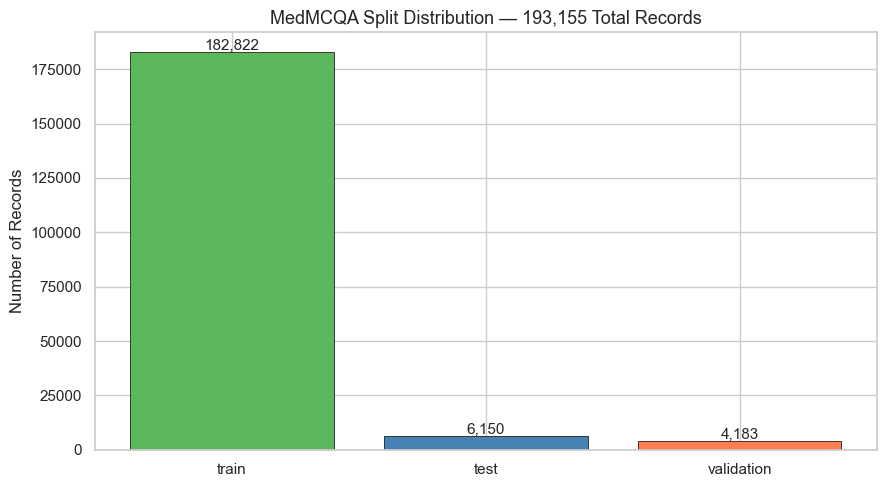

In [3]:
splits = ['train','test','validation']
sizes = [result[s]['metadata']['n_samples'] for s in splits]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(splits, sizes, color=['#5cb85c','steelblue','coral'],
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
            f'{val:,}', ha='center', fontsize=11)
ax.set_title('MedMCQA Split Distribution — 193,155 Total Records', fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correct Answer Distribution

Slight bias toward option A (29.3%) — typical exam question design pattern.

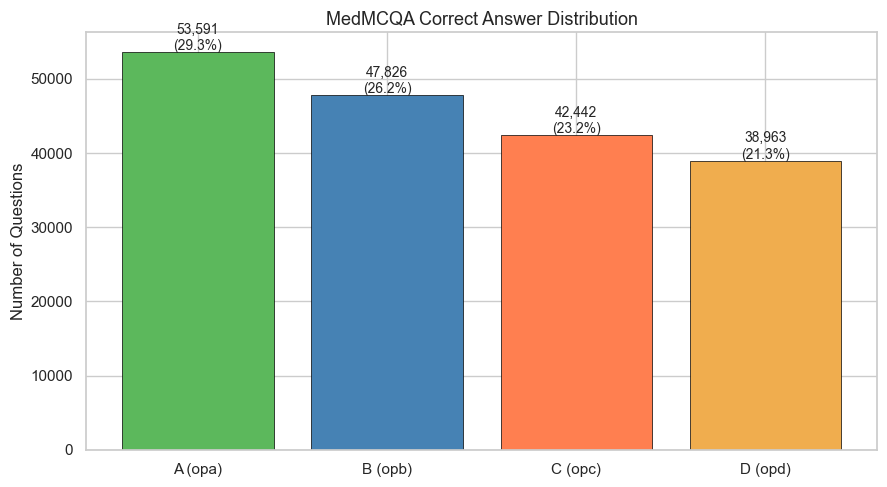

Answer A most common correct (29.3%) — 8% spread from A to D


In [4]:
label_counts = df['label'].value_counts().sort_index()
label_names = [OPTION_LABELS[i] for i in range(4)]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(label_names, [label_counts[i] for i in range(4)],
              color=OPTION_COLORS, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [label_counts[i] for i in range(4)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
ax.set_title('MedMCQA Correct Answer Distribution', fontsize=13)
ax.set_ylabel('Number of Questions')
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_answer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Answer A most common correct (29.3%) — 8% spread from A to D')

## 3. Subject Distribution — 21 Medical Subjects

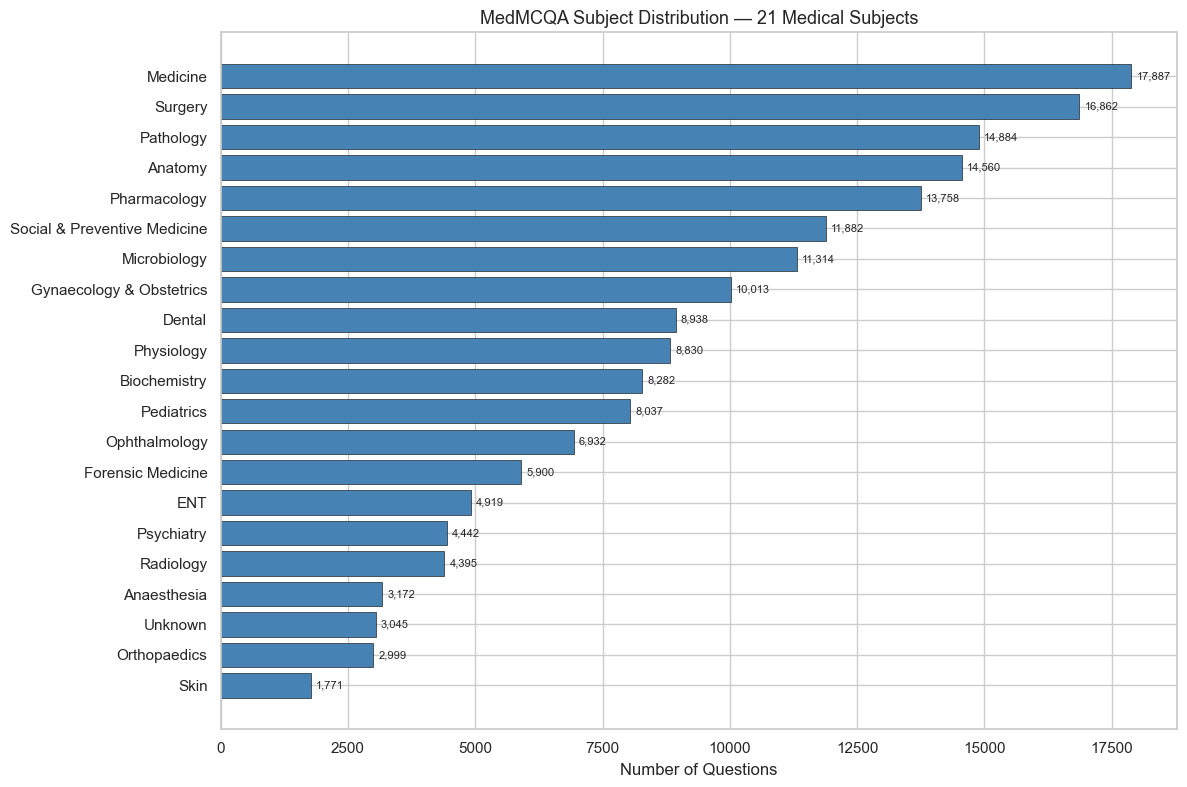

Medicine (17,887) and Surgery (16,862) dominate


In [5]:
subj_counts = df['subject_name'].value_counts()

fig, ax = plt.subplots(figsize=(12,8))
ax.barh(subj_counts.index[::-1], subj_counts.values[::-1],
        color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('MedMCQA Subject Distribution — 21 Medical Subjects', fontsize=13)
ax.set_xlabel('Number of Questions')
for i, val in enumerate(subj_counts.values[::-1]):
    ax.text(val+100, i, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Medicine (17,887) and Surgery (16,862) dominate')

## 4. Top 20 Topics

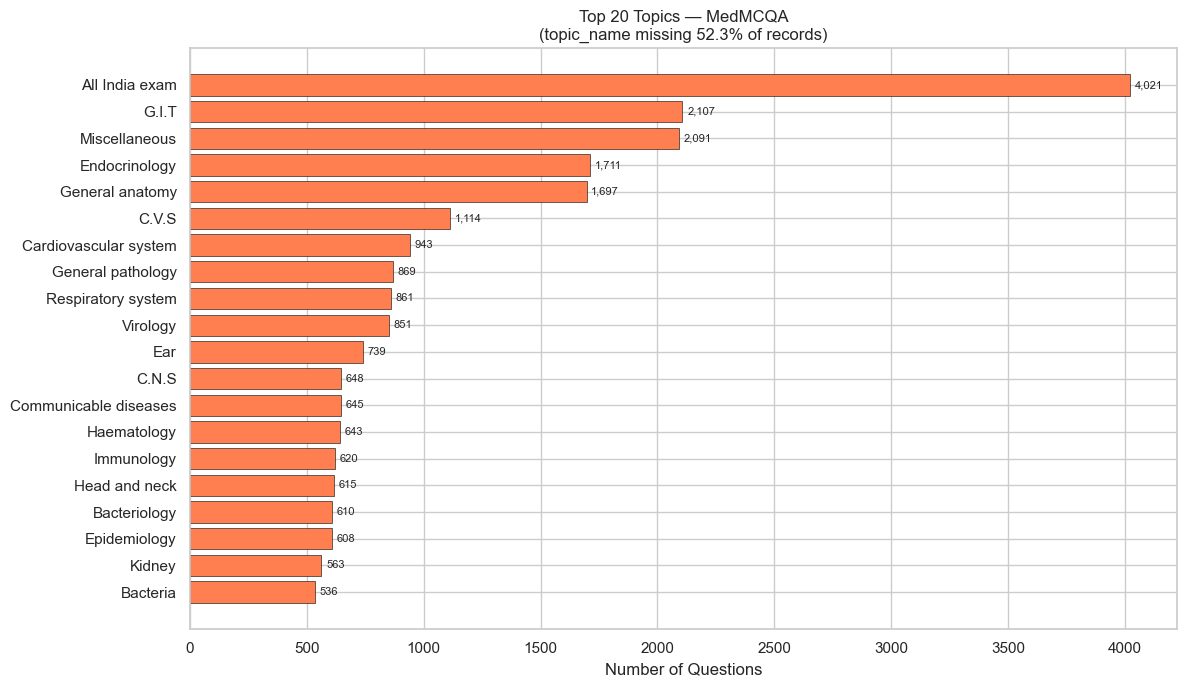

All India exam (4,021) and GIT (2,107) top topics


In [6]:
topic_counts = df['topic_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(topic_counts.index[::-1], topic_counts.values[::-1],
        color='coral', edgecolor='black', linewidth=0.4)
ax.set_title(f'Top 20 Topics — MedMCQA\n(topic_name missing {df["topic_name"].isna().mean():.1%} of records)',
             fontsize=12)
ax.set_xlabel('Number of Questions')
for i, val in enumerate(topic_counts.values[::-1]):
    ax.text(val+20, i, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_topics.png', dpi=150, bbox_inches='tight')
plt.show()
print('All India exam (4,021) and GIT (2,107) top topics')

## 5. Question Length by Subject

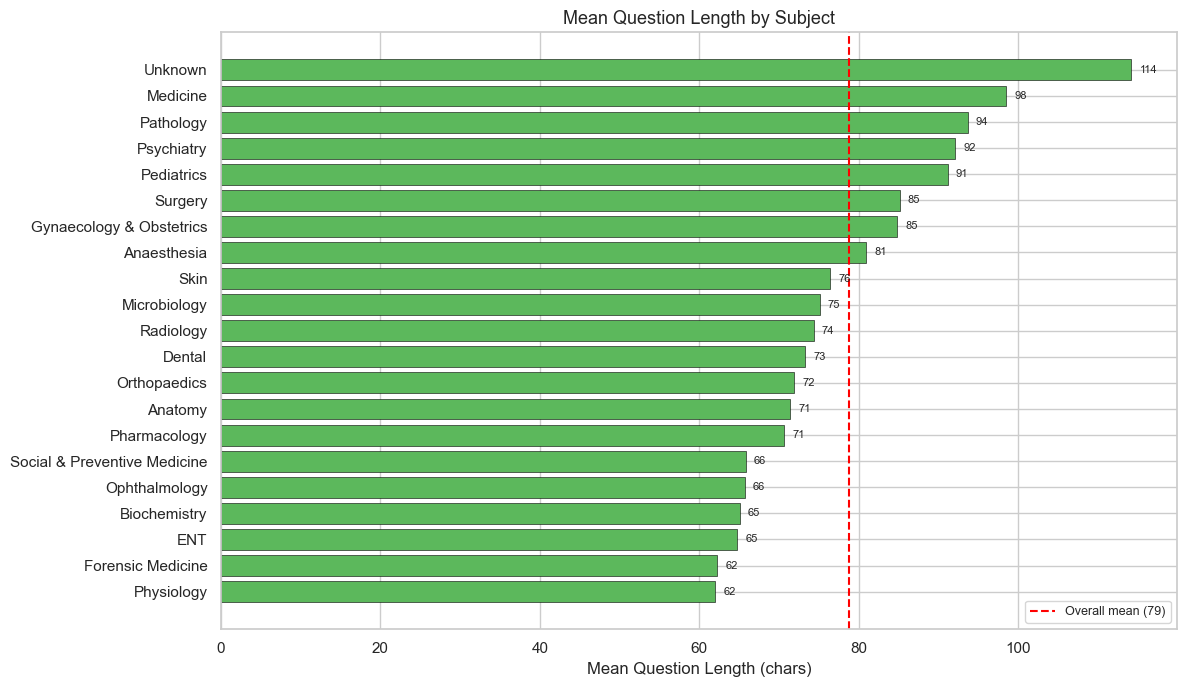

Medicine (98) and Pathology (94) have longest questions


In [7]:
subj_len = df.groupby('subject_name')['q_len'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(subj_len.index[::-1], subj_len.values[::-1],
        color='#5cb85c', edgecolor='black', linewidth=0.4)
ax.axvline(x=df['q_len'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["q_len"].mean():.0f})')
ax.set_title('Mean Question Length by Subject', fontsize=13)
ax.set_xlabel('Mean Question Length (chars)')
ax.legend(fontsize=9)
for i, val in enumerate(subj_len.values[::-1]):
    ax.text(val+1, i, f'{val:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_question_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Medicine (98) and Pathology (94) have longest questions')

## 6. Answer Option Length Comparison

All four options have nearly identical mean length (18 chars) — balanced MCQ design.

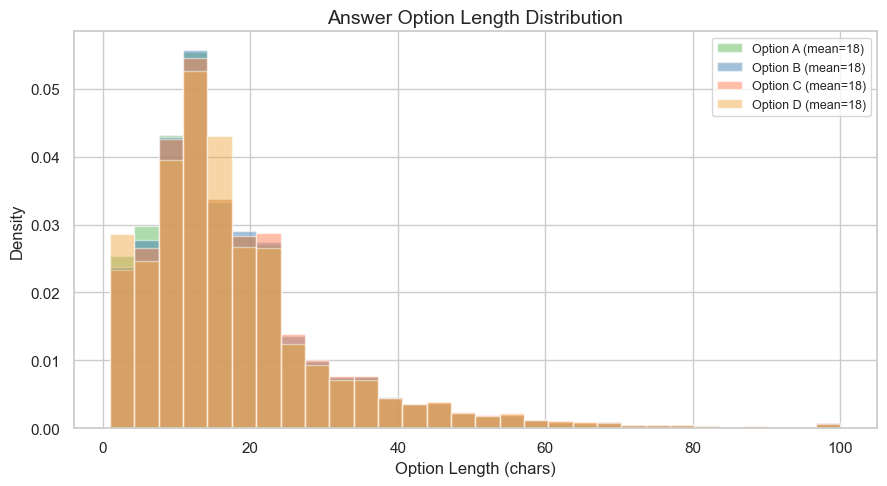

All options nearly identical length — balanced MCQ design, no option length bias


In [8]:
fig, ax = plt.subplots(figsize=(9,5))
opt_cols = ['opa_len','opb_len','opc_len','opd_len']
opt_labels = ['Option A','Option B','Option C','Option D']
for col, label, color in zip(opt_cols, opt_labels, OPTION_COLORS):
    ax.hist(df[col].clip(upper=100), bins=30, alpha=0.5, density=True,
            color=color, label=f'{label} (mean={df[col].mean():.0f})')
ax.set_title('Answer Option Length Distribution', fontsize=14)
ax.set_xlabel('Option Length (chars)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_option_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('All options nearly identical length — balanced MCQ design, no option length bias')

## 7. Explanation Coverage by Subject

Dental subject only 44% explanation coverage — significant gap for RAG retrieval.

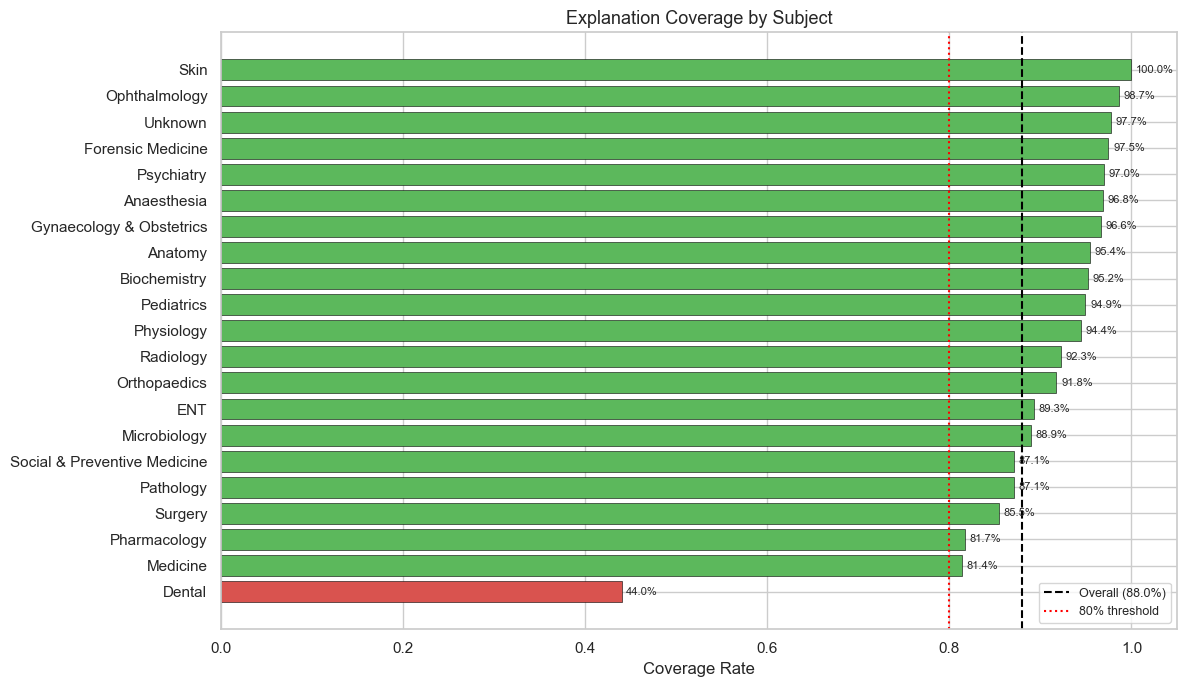

Dental 44% — lowest coverage; may limit RAG retrieval quality for dental questions


In [9]:
exp_by_subj = df.groupby('subject_name')['has_exp'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12,7))
colors = ['#d9534f' if v < 0.8 else '#5cb85c' for v in exp_by_subj.values]
ax.barh(exp_by_subj.index, exp_by_subj.values, color=colors,
        edgecolor='black', linewidth=0.4)
ax.axvline(x=df['has_exp'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["has_exp"].mean():.1%})')
ax.axvline(x=0.8, color='red', linestyle=':', linewidth=1.5, label='80% threshold')
ax.set_title('Explanation Coverage by Subject', fontsize=13)
ax.set_xlabel('Coverage Rate')
ax.legend(fontsize=9)
for i, val in enumerate(exp_by_subj.values):
    ax.text(val+0.005, i, f'{val:.1%}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_explanation_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dental 44% — lowest coverage; may limit RAG retrieval quality for dental questions')

## 8. Missing Values

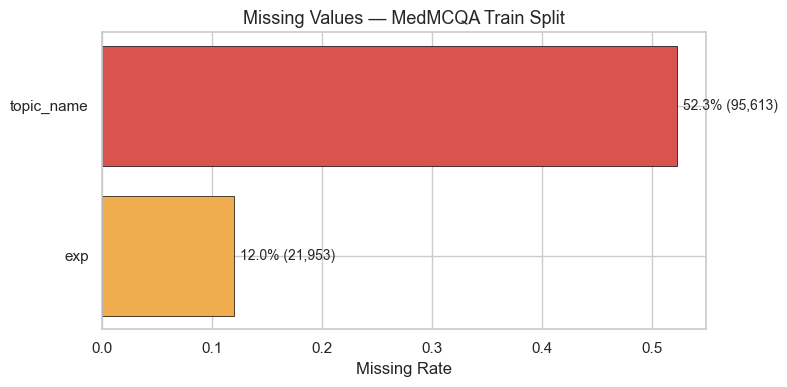

topic_name 52.3% missing — subject_name used as primary grouping in ORACLE


In [10]:
missing_cols = ['exp','topic_name']
missing_vals = [df[c].isna().sum() for c in missing_cols]
missing_pcts = [df[c].isna().mean() for c in missing_cols]

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(missing_cols, missing_pcts,
               color=['#f0ad4e','#d9534f'], edgecolor='black', linewidth=0.5)
ax.set_title('Missing Values — MedMCQA Train Split', fontsize=13)
ax.set_xlabel('Missing Rate')
for bar, val, n in zip(bars, missing_pcts, missing_vals):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.1%} ({n:,})', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('topic_name 52.3% missing — subject_name used as primary grouping in ORACLE')

## 9. Question Length Distribution

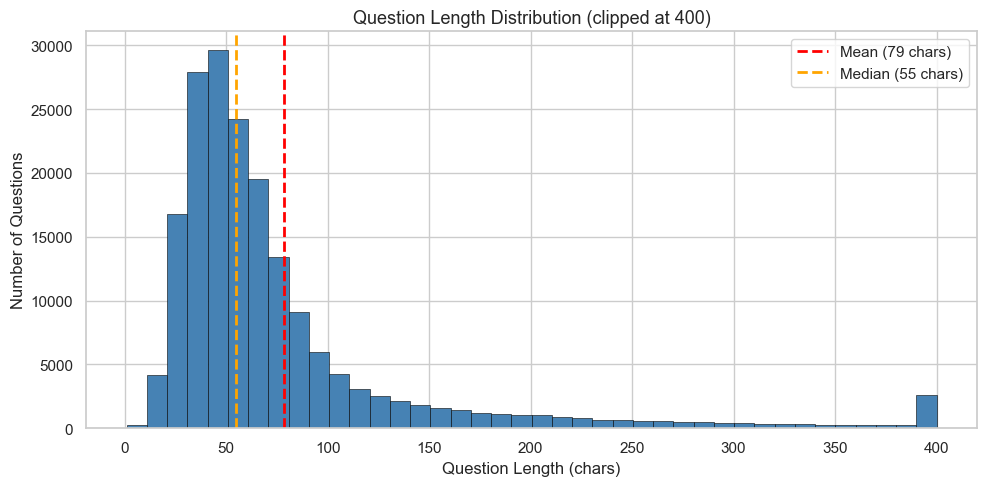

Long tail — max 1568 chars; right-skewed distribution


In [11]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df['q_len'].clip(upper=400), bins=40, color='steelblue',
        edgecolor='black', linewidth=0.4)
ax.axvline(x=df['q_len'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean ({df["q_len"].mean():.0f} chars)')
ax.axvline(x=df['q_len'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median ({df["q_len"].median():.0f} chars)')
ax.set_title('Question Length Distribution (clipped at 400)', fontsize=13)
ax.set_xlabel('Question Length (chars)')
ax.set_ylabel('Number of Questions')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_question_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Long tail — max {df["q_len"].max()} chars; right-skewed distribution')

## 10. Answer Bias by Subject

Answer A bias is NOT uniform across subjects. Orthopaedics (A-D gap=15.7%) vs Gynaecology (4.6%) — 3x difference. Subject-specific answer bias could affect ORACLE retrieval evaluation.

Loading MedMCQA train split...


  Records:     182,822
  Subjects:    21 unique medical subjects


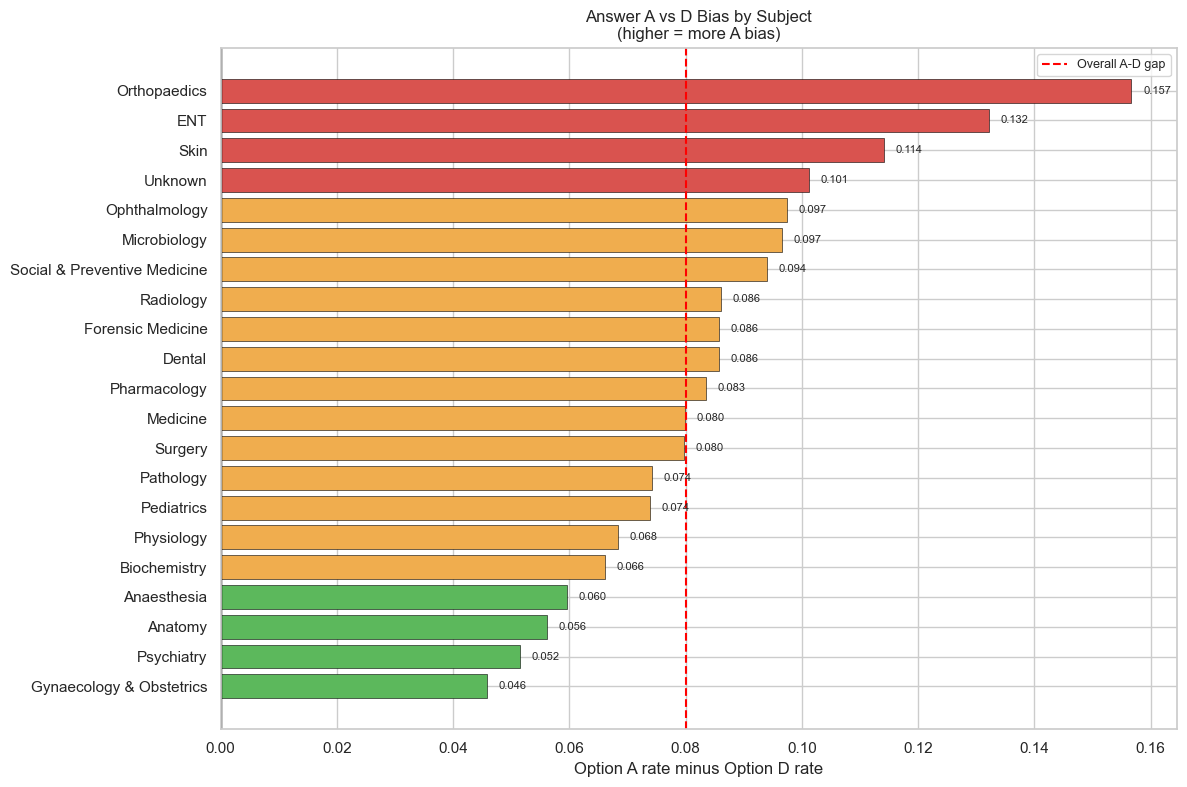

Orthopaedics A-D gap 15.7% vs Gynaecology 4.6% — 3x difference


In [12]:
from medmcqa_loader import load_medmcqa
result_train = load_medmcqa(split='train')
df_full = result_train['data'].copy()
df_full['label'] = result_train['labels'].values

pivot = df_full.groupby('subject_name')['label'].value_counts(normalize=True).unstack().fillna(0)
pivot.columns = ['A','B','C','D']
pivot['A_minus_D'] = pivot['A'] - pivot['D']
pivot = pivot.sort_values('A_minus_D', ascending=True)

fig, ax = plt.subplots(figsize=(12,8))
colors = ['#d9534f' if v > 0.1 else '#5cb85c' if v < 0.06 else '#f0ad4e' for v in pivot['A_minus_D']]
ax.barh(pivot.index, pivot['A_minus_D'], color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=(df['label']==0).mean()-(df['label']==3).mean(), color='red',
           linestyle='--', linewidth=1.5, label='Overall A-D gap')
ax.set_title('Answer A vs D Bias by Subject\n(higher = more A bias)', fontsize=12)
ax.set_xlabel('Option A rate minus Option D rate')
ax.legend(fontsize=9)
for i, (subj, row) in enumerate(pivot.iterrows()):
    ax.text(row['A_minus_D']+0.002, i, f'{row["A_minus_D"]:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_answer_bias_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()
print('Orthopaedics A-D gap 15.7% vs Gynaecology 4.6% — 3x difference')

## 11. Explanation Length by Subject

Explanation length varies significantly by subject — directly impacts RAG retrieval chunk size. Unknown (793 chars) and Medicine (657 chars) have longest explanations. Max 22,525 chars — extreme outliers require chunking strategy in ORACLE Stage 1.

Loading MedMCQA train split...


  Records:     182,822
  Subjects:    21 unique medical subjects


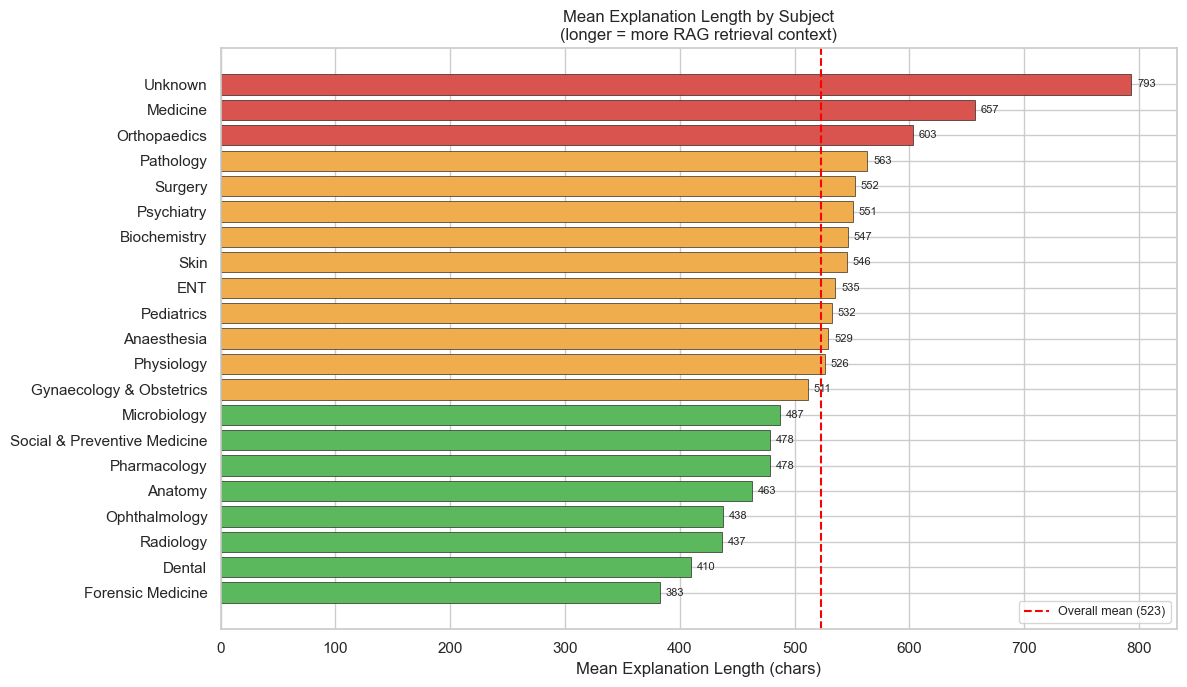

Unknown (793) and Medicine (657) longest — chunking strategy critical for ORACLE Stage 1


In [13]:
from medmcqa_loader import load_medmcqa
result_t = load_medmcqa(split='train')
df_exp = result_t['data'].copy()
df_exp['label'] = result_t['labels'].values
df_exp['exp_len'] = df_exp['exp'].astype(str).str.len()

exp_by_subj = df_exp[df_exp['exp'].notna()].groupby('subject_name')['exp_len'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12,7))
colors = ['#d9534f' if v > 600 else '#f0ad4e' if v > 500 else '#5cb85c' for v in exp_by_subj.values]
ax.barh(exp_by_subj.index, exp_by_subj.values, color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df_exp[df_exp['exp'].notna()]['exp_len'].mean(), color='red',
           linestyle='--', linewidth=1.5, label=f'Overall mean ({df_exp[df_exp["exp"].notna()]["exp_len"].mean():.0f})')
ax.set_title('Mean Explanation Length by Subject\n(longer = more RAG retrieval context)',
             fontsize=12)
ax.set_xlabel('Mean Explanation Length (chars)')
ax.legend(fontsize=9)
for i, val in enumerate(exp_by_subj.values):
    ax.text(val+5, i, f'{val:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/medmcqa_explanation_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Unknown (793) and Medicine (657) longest — chunking strategy critical for ORACLE Stage 1')

## 12. Key Observations

**Scale:** 193,155 records across 21 medical subjects and 2,388 topics. Largest medical MCQ dataset in ORACLE pipeline.

**Answer bias:** Option A is correct 29.3% of the time vs D at 21.3%. 8% spread — mild but consistent exam design pattern.

**Subject distribution:** Medicine (17,887) and Surgery (16,862) dominate. Medicine questions longest (mean 98 chars) — complex clinical scenarios.

**Explanation coverage:** 88% overall. Dental only 44% — significant gap. Explanations are the primary text for RAG retrieval in ORACLE Stage 1.

**Missing data:** topic_name missing 52.3% — subject_name used as primary grouping. Explanations missing 12%.

**ORACLE implication:** ORACLE Stage 1 uses question + explanation as retrieval corpus. MedMCQA establishes broad medical knowledge retrieval baseline before patient accessibility evaluation via MedQuAD and PLABA.